# STEP A : EDA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load ---
df = pd.read_csv(r"D:\Project\ElevateLabs\HR Attrition\data\WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
df.head()

# --- Nulls & dtypes ---
print(df.isnull().sum())
print(df.dtypes)


(1470, 35)
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0

In [2]:

# --- Class balance ---
attr_counts = df['Attrition'].value_counts(normalize=True) * 100
print(attr_counts)  # expect ~84% No / 16% Yes


Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


## Class Balance
The target variable `Attrition` is imbalanced: ~84% No vs ~16% Yes.
This will be handled explicitly in preprocessing (class_weight='balanced' or SMOTE)
and evaluation will prioritize Recall/F1 over Accuracy.

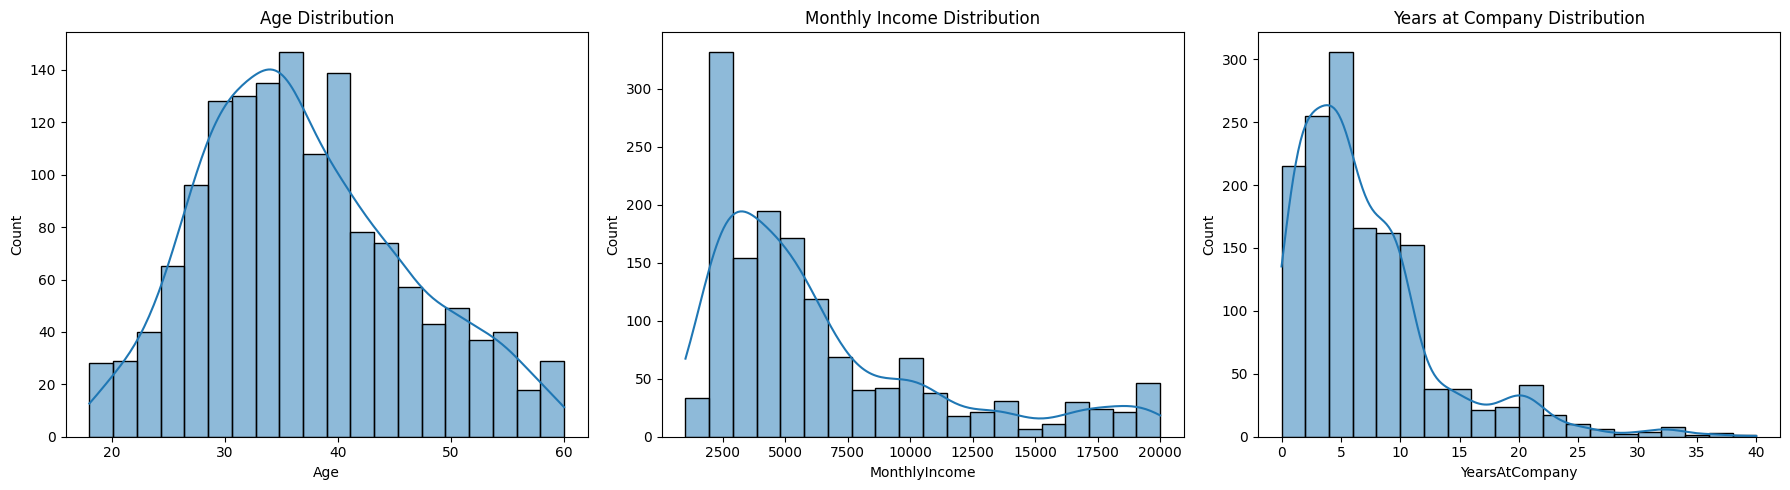

In [3]:

# ============================================================
# UNIVARIATE ANALYSIS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0]).set_title("Age Distribution")
sns.histplot(df['MonthlyIncome'], bins=20, kde=True, ax=axes[1]).set_title("Monthly Income Distribution")
sns.histplot(df['YearsAtCompany'], bins=20, kde=True, ax=axes[2]).set_title("Years at Company Distribution")
plt.tight_layout()
plt.savefig("univariate_analysis.png")
plt.show()



Attrition rate (%) by Department:
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


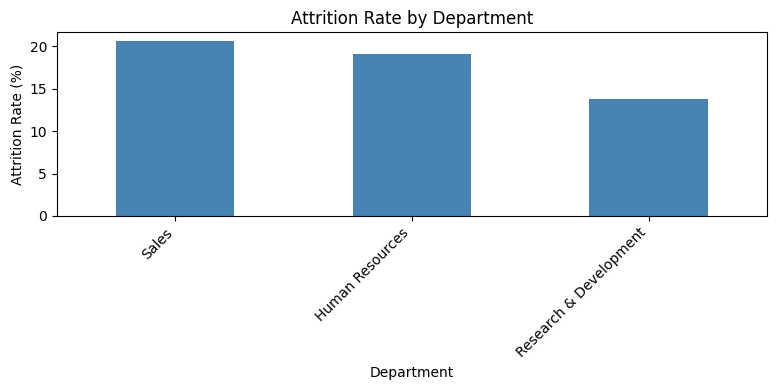


Attrition rate (%) by JobRole:
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


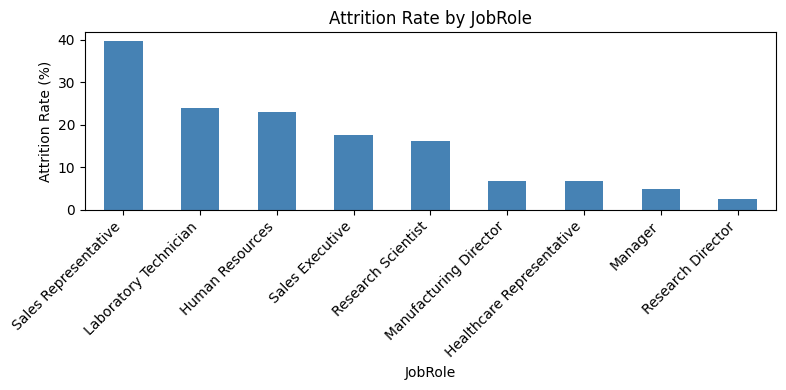


Attrition rate (%) by OverTime:
OverTime
Yes    30.528846
No     10.436433
Name: Attrition, dtype: float64


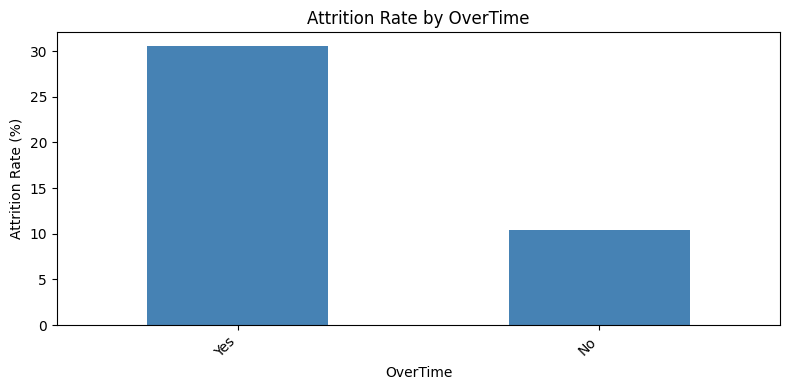


Attrition rate (%) by MaritalStatus:
MaritalStatus
Single      25.531915
Married     12.481426
Divorced    10.091743
Name: Attrition, dtype: float64


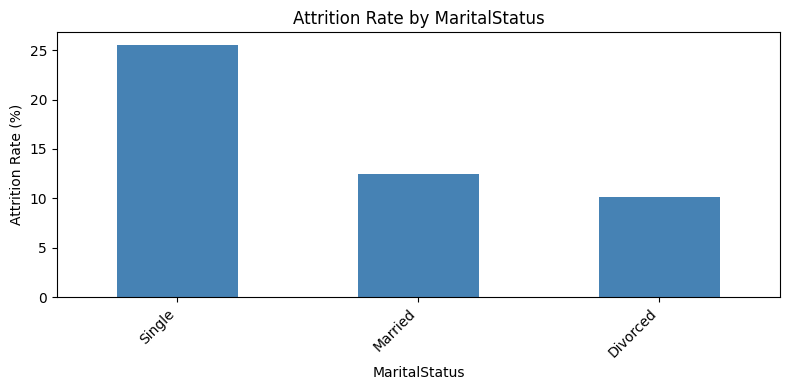


Attrition rate (%) by JobSatisfaction:
JobSatisfaction
1    22.837370
3    16.515837
2    16.428571
4    11.328976
Name: Attrition, dtype: float64


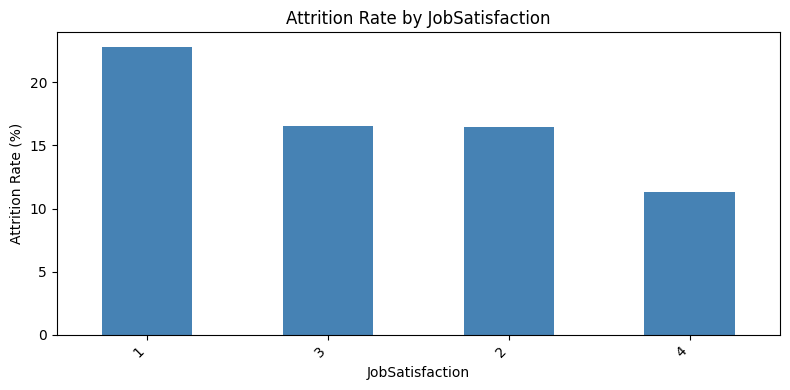

In [4]:

# ============================================================
# BIVARIATE ANALYSIS — Attrition rate by category
# ============================================================
def attrition_rate_by(col):
    rate = df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
    return rate.sort_values(ascending=False)

for col in ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'JobSatisfaction']:
    rates = attrition_rate_by(col)
    print(f"\nAttrition rate (%) by {col}:\n{rates}")

    plt.figure(figsize=(8, 4))
    rates.plot(kind='bar', color='steelblue')
    plt.title(f"Attrition Rate by {col}")
    plt.ylabel("Attrition Rate (%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"attrition_by_{col}.png")
    plt.show()

Attrition rate (%) by Salary Band:
 SalaryBand
Low          29.268293
Medium       14.207650
High         10.626703
Very High    10.326087
Name: Attrition, dtype: float64


C:\Users\thoma\AppData\Local\Temp\ipykernel_5692\3578144688.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_attr = df.groupby('SalaryBand')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)


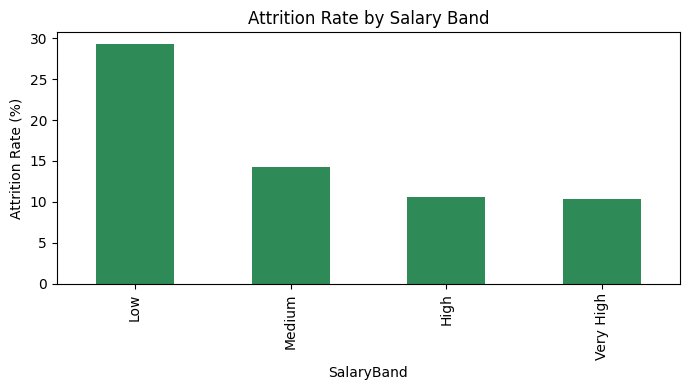

In [5]:
# ============================================================
# SALARY BAND ANALYSIS
# ============================================================
df['SalaryBand'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

salary_attr = df.groupby('SalaryBand')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Attrition rate (%) by Salary Band:\n", salary_attr)

plt.figure(figsize=(7, 4))
salary_attr.plot(kind='bar', color='seagreen')
plt.title("Attrition Rate by Salary Band")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.savefig("attrition_by_salary_band.png")
plt.show()


Attrition rate (%) by Years Since Last Promotion:
 PromotionBucket
0      18.932874
1-2    14.728682
3-5    10.126582
5+     16.279070
Name: Attrition, dtype: float64


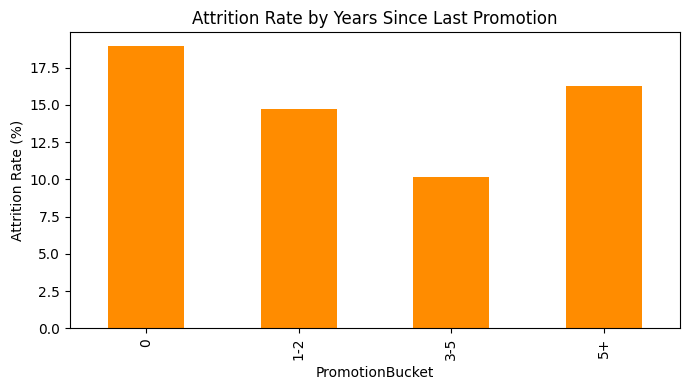

In [6]:

# ============================================================
# PROMOTION TREND ANALYSIS
# ============================================================
def promo_bucket(years):
    if years == 0:
        return '0'
    elif years <= 2:
        return '1-2'
    elif years <= 5:
        return '3-5'
    else:
        return '5+'

df['PromotionBucket'] = df['YearsSinceLastPromotion'].apply(promo_bucket)

promo_attr = df.groupby('PromotionBucket')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
promo_attr = promo_attr.reindex(['0', '1-2', '3-5', '5+'])
print("Attrition rate (%) by Years Since Last Promotion:\n", promo_attr)

plt.figure(figsize=(7, 4))
promo_attr.plot(kind='bar', color='darkorange')
plt.title("Attrition Rate by Years Since Last Promotion")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.savefig("attrition_by_promotion_bucket.png")
plt.show()


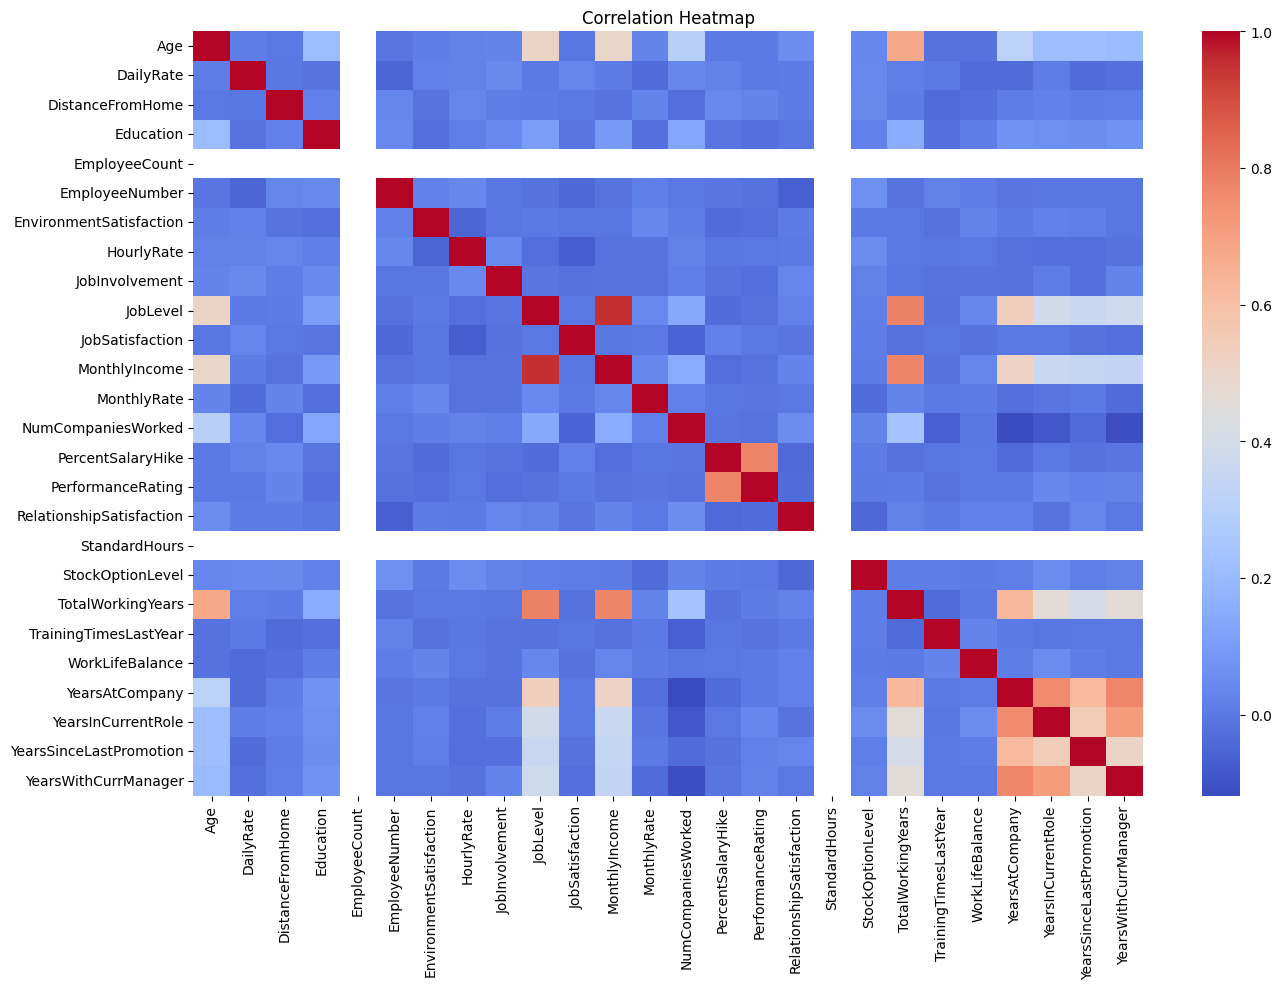

In [7]:

# ============================================================
# CORRELATION HEATMAP (numeric features)
# ============================================================
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(r"D:\Project\ElevateLabs\HR Attrition\outputs\correlation_heatmap.png")
plt.show()

## Key EDA Findings

1. **OverTime** is the strongest single driver — employees working overtime churn at
   ~30.5% vs 10.4% for those who don't.
2. **Salary Band**: Low-income employees churn at 29.3% vs 10.3% for Very High income —
   attrition drops sharply moving from Low to Medium, then flattens.
3. **Promotion Trend** shows a U-shaped pattern: 18.9% attrition at 0 years since last
   promotion, dropping to 10.1% at 3-5 years, then rising again to 16.3% at 5+ years —
   not a simple linear relationship.
4. **JobRole**: Sales Representatives churn highest (~40%), far above Managers and
   Research Directors (~3-5%) — role-level risk varies more than department-level.
5. **Department**: Sales (20.6%) and HR (19.1%) churn well above R&D (13.8%).
6. **MaritalStatus**: Single employees churn at 25.5% vs 12.4% (Married) and
   10.1% (Divorced).
7. **JobSatisfaction**: Attrition decreases roughly monotonically from 22.8% (level 1)
   to 11.3% (level 4).


## Correlation Heatmap Notes
No unexpected multicollinearity issues. Expected clusters (JobLevel–MonthlyIncome–
TotalWorkingYears–YearsAtCompany) are logically correlated. Constant-value columns
(EmployeeCount, StandardHours, Over18) show as blank/NaN and will be dropped before
modeling.

# STEP B : PRE-PROCESSING

In [8]:
# ============================================================
# STEP B — PREPROCESSING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop constant/non-informative columns identified in EDA
df_model = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])

# Encode target
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# One-hot encode categoricals (excluding target)
df_model = pd.get_dummies(df_model, drop_first=True)

# Split features/target
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

# Train/test split — stratified due to class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

# Scale numeric features (needed for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (1176, 50)  Test shape: (294, 50)
Train class balance:
 Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Test class balance:
 Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


# STEP C : MODELING

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.789116   0.409639  0.723404  0.523077  0.820829
1        Random Forest  0.836735   0.428571  0.063830  0.111111  0.787923


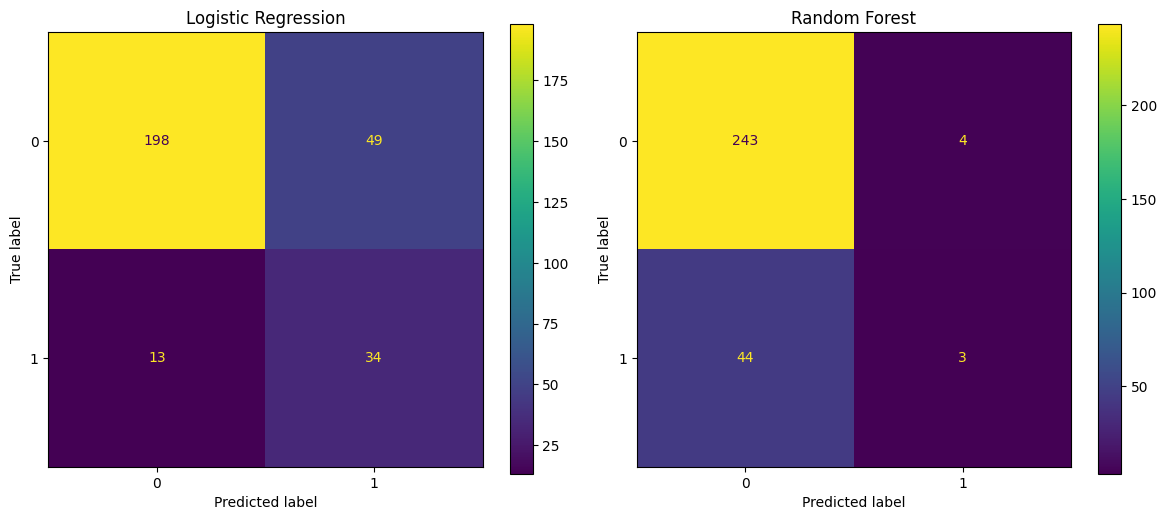

In [9]:
# ============================================================
# STEP C — MODELING
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

# --- Model 1: Logistic Regression (baseline) ---
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# --- Model 2: Random Forest (comparison) ---
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf.fit(X_train, y_train)   # tree models don't need scaling
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# --- Evaluation function ---
def evaluate(y_true, y_pred, y_proba, name):
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }
    return metrics

results = pd.DataFrame([
    evaluate(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression'),
    evaluate(y_test, y_pred_rf, y_proba_rf, 'Random Forest')
])
print(results)
results.to_csv('../outputs/model_metrics.csv', index=False)

# --- Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(ax=axes[0])
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(ax=axes[1])
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png')
plt.show()

## Model Selection
Logistic Regression (class_weight='balanced') was selected as the final model over
Random Forest. Despite lower accuracy (78.9% vs 83.7%), LR achieves far superior
Recall (72.3% vs 6.4%) and F1 (0.523 vs 0.111) — critical since missing an actual
churner is costlier than a false alarm. Random Forest's high accuracy is misleading:
it predicts the majority class almost exclusively and fails to identify true leavers.
ROC-AUC also favors LR (0.821 vs 0.788).

# STEP D — SHAP EXPLAINABILITY

c:\Users\thoma\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


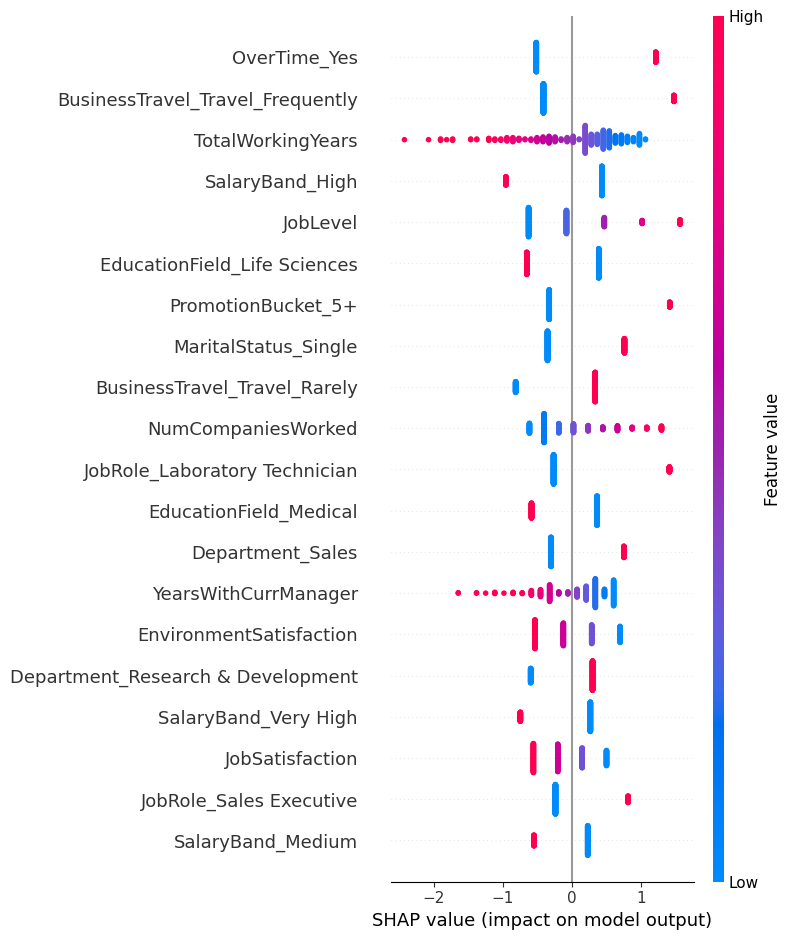

In [10]:
# ============================================================
# STEP D — SHAP EXPLAINABILITY
# ============================================================
import shap

# LinearExplainer is exact and fast for Logistic Regression
explainer = shap.LinearExplainer(log_reg, X_train_scaled, feature_names=X.columns)
shap_values = explainer(X_test_scaled)

# --- Global feature importance: SHAP summary plot ---
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png')
plt.show()


In [11]:

# --- Local explainability: force plots for 2-3 high-risk employees ---
# Identify top 3 highest predicted-probability employees in test set
top_risk_idx = np.argsort(y_proba_lr)[-3:][::-1]

shap.initjs()
for i in top_risk_idx:
    print(f"Employee index {i} — Predicted churn probability: {y_proba_lr[i]:.2f}")
    display(shap.force_plot(
        explainer.expected_value, shap_values.values[i], X_test.iloc[i],
        feature_names=X.columns
    ))

Employee index 214 — Predicted churn probability: 0.99


Employee index 92 — Predicted churn probability: 0.99


Employee index 200 — Predicted churn probability: 0.98


## SHAP Interpretation

The SHAP summary plot confirms **OverTime (Yes)** and **frequent Business Travel** as
the strongest global drivers pushing predictions toward attrition, followed by low
**TotalWorkingYears** and low **JobLevel** — early-career, less-tenured employees are
consistently flagged as higher risk. **High/Very High SalaryBand** and being in the
5+ years PromotionBucket both pull predictions in opposite directions depending on
value, showing salary and promotion timing modulate risk rather than acting alone.
At the individual level, the top 3 highest-risk employees (indices 214, 92, 200 —
predicted churn probability 0.98-0.99) share a consistent profile: Single marital
status, low TotalWorkingYears, OverTime=Yes, and JobRole=Sales Representative —
directly matching the global feature importance and validating the model's local
explanations against the population-level trend.

# STEP E (prep) — EXPORT HIGH-RISK EMPLOYEES CSV FOR POWER BI

In [12]:
# ============================================================
# STEP E (prep) — EXPORT HIGH-RISK EMPLOYEES CSV FOR POWER BI
# ============================================================

# Build a results dataframe aligned with X_test
risk_df = X_test.copy()
risk_df['Actual_Attrition'] = y_test.values
risk_df['Predicted_Attrition'] = y_pred_lr
risk_df['Attrition_Probability'] = y_proba_lr

# Bring back readable original columns (before one-hot encoding) for context
# using the original df, matched by X_test's index
readable_cols = ['Age', 'Department', 'JobRole', 'MonthlyIncome', 'OverTime',
                  'JobSatisfaction', 'YearsAtCompany', 'MaritalStatus']
readable_df = df.loc[X_test.index, readable_cols]

export_df = pd.concat([readable_df, risk_df[['Attrition_Probability',
                                              'Actual_Attrition',
                                              'Predicted_Attrition']]], axis=1)

# Sort by highest risk, take top 10 (spec requirement) — 
# but export full test set too, useful for the dashboard table/slicers
export_df_sorted = export_df.sort_values('Attrition_Probability', ascending=False)

top10 = export_df_sorted.head(10)
print(top10)

# Save both: top 10 (spec deliverable) and full scored test set (for dashboard flexibility)
top10.to_csv('../data/high_risk_employees.csv', index=False)
export_df_sorted.to_csv('../data/all_scored_employees.csv', index=False)

      Age              Department               JobRole  MonthlyIncome  \
357    21                   Sales  Sales Representative           2174   
911    25                   Sales  Sales Representative           1118   
688    19                   Sales  Sales Representative           2121   
946    40                   Sales       Sales Executive           9094   
762    26  Research & Development    Research Scientist           2042   
36     50                   Sales  Sales Representative           2683   
514    33  Research & Development    Research Scientist           3348   
132    31                   Sales       Sales Executive           4559   
829    33                   Sales       Sales Executive           8224   
1021   25                   Sales  Sales Representative           4400   

     OverTime  JobSatisfaction  YearsAtCompany MaritalStatus  \
357       Yes                2               3        Single   
911       Yes                4               1        Sin

In [13]:
# Re-export dashboard data with EmployeeNumber included
df.to_csv('../data/hr_dashboard_data.csv', index=False)  # already has EmployeeNumber if you didn't drop it from df

# Re-export high-risk employees with EmployeeNumber
readable_cols = ['EmployeeNumber', 'Age', 'Department', 'JobRole', 'MonthlyIncome', 'OverTime',
                  'JobSatisfaction', 'YearsAtCompany', 'MaritalStatus']
readable_df = df.loc[X_test.index, readable_cols]
export_df = pd.concat([readable_df, risk_df[['Attrition_Probability', 'Actual_Attrition', 'Predicted_Attrition']]], axis=1)
export_df_sorted = export_df.sort_values('Attrition_Probability', ascending=False)
top10 = export_df_sorted.head(10)
top10.to_csv('../data/high_risk_employees.csv', index=False)